In [1]:
import os
import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    T5ForConditionalGeneration,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq,
    AutoModelForSeq2SeqLM
)

/workspace/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
MODEL_NAME = "google/long-t5-local-base"
DATASET_NAME = "neo4j/text2cypher-2024v1"
MAX_INPUT_LEN = 16384
MAX_TARGET_LEN = 16384

INSTRUCTION_PREFIX = (
    "Generate Cypher statement to query a graph database.\n"
    "Schema: {schema}\nQuestion: {question}\nCypher: "
)

OUTPUT_DIR = "./flan_t5_text2cypher/"

# Full Training

In [3]:
from dotenv import load_dotenv

load_dotenv()

False

In [12]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

Loading weights: 100%|██████████| 281/281 [00:00<00:00, 1133.10it/s, Materializing param=shared.weight]                                                           
LongT5ForConditionalGeneration LOAD REPORT from: google/long-t5-local-base
Key                         | Status  | 
----------------------------+---------+-
decoder.embed_tokens.weight | MISSING | 
lm_head.weight              | MISSING | 
encoder.embed_tokens.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [5]:
dataset = load_dataset(DATASET_NAME)

In [6]:
train_ds = dataset["train"]
eval_ds = dataset["test"]

In [7]:
def preprocess(example, tokenizer, max_input_len, max_target_len):
    input_text = INSTRUCTION_PREFIX.format(schema=example["schema"], question=example["question"])
    target_text = example["cypher"]

    model_inputs = tokenizer(
        input_text, max_length=max_input_len, padding=False, truncation=True
    )
    labels = tokenizer(
        target_text, max_length=max_target_len, padding=False, truncation=True
    )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

In [8]:
tokenize_fn = lambda example: preprocess(
        example, tokenizer, MAX_INPUT_LEN, MAX_TARGET_LEN
)

train_tokenized = train_ds.map(tokenize_fn, remove_columns=train_ds.column_names, load_from_cache_file=True)

In [9]:
eval_tokenized = (
    eval_ds.map(tokenize_fn, remove_columns=eval_ds.column_names, load_from_cache_file=True)
    if eval_ds
    else None
)

In [ ]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer, model=model, padding=True, label_pad_token_id=-100
)

training_args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=4,
    bf16=False,
    fp16=False,
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    logging_steps=5,
    predict_with_generate=False,
    report_to="tensorboard",
    seed=42,
    lr_scheduler_type="cosine",
    learning_rate=3e-4,   # 3e-4 is too aggressive for fine-tuning; caused NaN grad norm
    # warmup_ratio=0.05,    # ~5% of total steps; more stable than a fixed 20-step warmup
    # max_grad_norm=1.0,
    dataloader_num_workers=0,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=eval_tokenized,
    processing_class=tokenizer,
    data_collator=data_collator,
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [22]:
trainer.train()
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

Step,Training Loss,Validation Loss


KeyboardInterrupt: 

In [ ]:
input_lens = [len(x) for x in train_tokenized["input_ids"]]
print(f"max: {max(input_lens)}, p95: {sorted(input_lens)[int(len(input_lens)*0.95)]}")

max: 4589, p95: 3578


# Relationships-Only Schema Training

Filters the dataset to entries containing a `"The relationships:"` section,
replaces the full schema with just that portion (dramatically reducing input
length), and trains a seq2seq model on a small subset with live loss curve logging.

In [36]:
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from transformers import TrainerCallback

# --- Config for this section ---
RELS_MODEL_NAME = "google/flan-t5-small"  # small model for fast iteration
TRAIN_SUBSET = 500
EVAL_SUBSET = 100
RELS_MAX_INPUT_LEN = 1024   # much shorter now that schema is compact
RELS_MAX_TARGET_LEN = 256
RELS_OUTPUT_DIR = "./flan_t5_rels_only/"

RELS_INSTRUCTION_PREFIX = (
    "Generate Cypher statement to query a graph database.\n"
    "Schema:\n{schema}\nQuestion: {question}\nCypher:"
)

### Filter & Replace Schema with Relationships Only

In [37]:
# Reload fresh copy of the dataset
rels_dataset = load_dataset(DATASET_NAME)

def extract_relationships_schema(example):
    """Replace full schema with only the 'The relationships:' portion."""
    schema = example["schema"]
    marker = "The relationships:"
    idx = schema.find(marker)
    if idx == -1:
        return {"schema": schema, "__has_rels": False}
    return {"schema": schema[idx:].strip(), "__has_rels": True}

for split in rels_dataset:
    rels_dataset[split] = rels_dataset[split].map(extract_relationships_schema)
    before = len(rels_dataset[split])
    rels_dataset[split] = rels_dataset[split].filter(lambda x: x["__has_rels"])
    rels_dataset[split] = rels_dataset[split].remove_columns(["__has_rels"])
    print(f"{split}: {before} -> {len(rels_dataset[split])} (kept entries with relationships)")

# Show example
print("\n--- Sample schema (after) ---")
print(rels_dataset["train"][0]["schema"])
print(f"\n--- Sample question ---")
print(rels_dataset["train"][0]["question"])
print(f"\n--- Sample cypher ---")
print(rels_dataset["train"][0]["cypher"])

train: 39554 -> 22360 (kept entries with relationships)
test: 4833 -> 2506 (kept entries with relationships)

--- Sample schema (after) ---
The relationships:
(:Filing)-[:BENEFITS]->(:Entity)
(:Filing)-[:CONCERNS]->(:Entity)
(:Filing)-[:ORIGINATOR]->(:Entity)
(:Entity)-[:FILED]->(:Filing)
(:Entity)-[:COUNTRY]->(:Country)

--- Sample question ---
Which 3 countries have the most entities linked as beneficiaries in filings?

--- Sample cypher ---
MATCH (f:Filing)-[:BENEFITS]->(e:Entity)-[:COUNTRY]->(c:Country) WITH c.name AS country, COUNT(e) AS entityCount ORDER BY entityCount DESC LIMIT 3 RETURN country, entityCount


### Take Small Subsets & Tokenize

In [38]:
rels_train_ds = rels_dataset["train"].shuffle(seed=42).select(range(min(TRAIN_SUBSET, len(rels_dataset["train"]))))
rels_eval_ds = rels_dataset["test"].shuffle(seed=42).select(range(min(EVAL_SUBSET, len(rels_dataset["test"]))))
print(f"Train subset: {len(rels_train_ds)},  Eval subset: {len(rels_eval_ds)}")

# Load model & tokenizer
rels_tokenizer = AutoTokenizer.from_pretrained(RELS_MODEL_NAME)
rels_model = AutoModelForSeq2SeqLM.from_pretrained(RELS_MODEL_NAME)

def rels_preprocess(example):
    input_text = RELS_INSTRUCTION_PREFIX.format(
        schema=example["schema"], question=example["question"]
    )
    target_text = example["cypher"]
    model_inputs = rels_tokenizer(
        input_text, max_length=RELS_MAX_INPUT_LEN, padding=False, truncation=True
    )
    labels = rels_tokenizer(
        target_text, max_length=RELS_MAX_TARGET_LEN, padding=False, truncation=True
    )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

rels_train_tok = rels_train_ds.map(rels_preprocess, remove_columns=rels_train_ds.column_names)
rels_eval_tok = rels_eval_ds.map(rels_preprocess, remove_columns=rels_eval_ds.column_names)

# Verify lengths are now reasonable
rels_input_lens = [len(x) for x in rels_train_tok["input_ids"]]
rels_label_lens = [len(x) for x in rels_train_tok["labels"]]
print(f"Input token lengths — max: {max(rels_input_lens)}, median: {sorted(rels_input_lens)[len(rels_input_lens)//2]}")
print(f"Label token lengths — max: {max(rels_label_lens)}, median: {sorted(rels_label_lens)[len(rels_label_lens)//2]}")

Train subset: 500,  Eval subset: 100


Loading weights: 100%|██████████| 190/190 [00:00<00:00, 1164.76it/s, Materializing param=shared.weight]                                                       
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Input token lengths — max: 826, median: 197
Label token lengths — max: 180, median: 62


### Train with Live Loss Curves

In [ ]:
import torch.nn.functional as F

class LivePlotCallback(TrainerCallback):
    """Plots train & eval loss curves live in the notebook."""

    def __init__(self):
        self.train_steps = []
        self.train_losses = []
        self.eval_steps = []
        self.eval_losses = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is None:
            return
        if "loss" in logs:
            self.train_steps.append(state.global_step)
            self.train_losses.append(logs["loss"])
        if "eval_loss" in logs:
            self.eval_steps.append(state.global_step)
            self.eval_losses.append(logs["eval_loss"])
        self._plot()

    def _plot(self):
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(8, 4))
        if self.train_steps:
            ax.plot(self.train_steps, self.train_losses, label="Train Loss", alpha=0.8)
        if self.eval_steps:
            ax.plot(self.eval_steps, self.eval_losses, "o-", label="Eval Loss", alpha=0.8)
        ax.set_xlabel("Step")
        ax.set_ylabel("Loss")
        ax.set_title("Relationships-Only Training Progress")
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        display(fig)
        plt.close(fig)

live_plot = LivePlotCallback()


class EntropyTrainer(Seq2SeqTrainer):
    """Logs token-level entropy and top-1 confidence alongside loss."""

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        outputs = model(**inputs)
        loss = outputs.loss

        # Only compute and log diagnostic metrics during training steps.
        # compute_loss is also called from prediction_step during evaluation;
        # calling self.log() there interferes with the Trainer's eval metric
        # aggregation and causes eval_loss / the custom metrics to appear as NaN.
        if self.model.training:
            logits = outputs.logits  # (batch, seq_len, vocab)
            labels = inputs.get("labels")
            mask = (labels != -100) if labels is not None else None

            if logits is not None and mask is not None and mask.any():
                probs = F.softmax(logits, dim=-1)
                log_probs = F.log_softmax(logits, dim=-1)

                # Token-level entropy: -sum(p * log(p))
                entropy = -(probs * log_probs).sum(dim=-1)  # (batch, seq_len)
                mean_entropy = entropy[mask].mean().item()

                # Top-1 confidence
                top1_conf = probs.max(dim=-1).values  # (batch, seq_len)
                mean_top1 = top1_conf[mask].mean().item()

                # Perplexity (exp of cross-entropy loss)
                ppl = torch.exp(loss).item()

                self.log({
                    "token_entropy": mean_entropy,
                    "top1_confidence": mean_top1,
                    "perplexity": ppl,
                })

        return (loss, outputs) if return_outputs else loss

In [ ]:
rels_data_collator = DataCollatorForSeq2Seq(
    tokenizer=rels_tokenizer, model=rels_model, padding=True, label_pad_token_id=-100
)

rels_training_args = Seq2SeqTrainingArguments(
    output_dir=RELS_OUTPUT_DIR,
    num_train_epochs=5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,
    bf16=torch.cuda.is_bf16_supported() if torch.cuda.is_available() else False,
    eval_strategy="steps",
    eval_steps=25,
    save_strategy="steps",
    save_steps=50,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    logging_steps=5,
    predict_with_generate=False,
    report_to="tensorboard",
    logging_dir=RELS_OUTPUT_DIR + "runs/",
    seed=42,
    lr_scheduler_type="cosine",
    learning_rate=1e-4,   # 3e-4 caused NaN grad norm; 1e-4 is safer for fine-tuning
    warmup_ratio=0.05,    # ~5% of total steps
    max_grad_norm=1.0,
    dataloader_num_workers=0,
)

rels_trainer = EntropyTrainer(
    model=rels_model,
    args=rels_training_args,
    train_dataset=rels_train_tok,
    eval_dataset=rels_eval_tok,
    processing_class=rels_tokenizer,
    data_collator=rels_data_collator,
    callbacks=[live_plot],
)

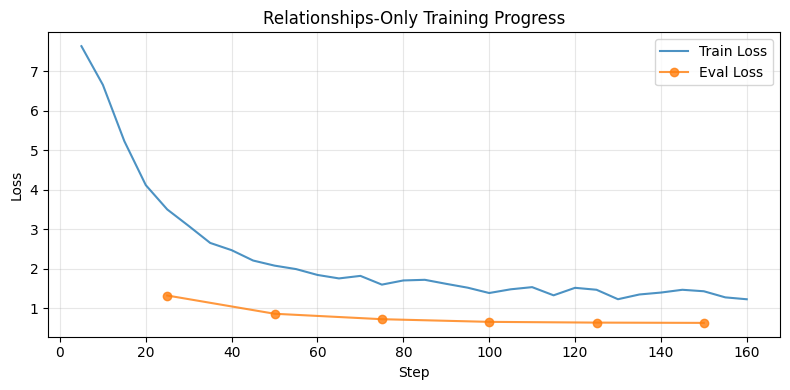

TrainOutput(global_step=160, training_loss=2.2951523780822756, metrics={'train_runtime': 79.5706, 'train_samples_per_second': 31.419, 'train_steps_per_second': 2.011, 'total_flos': 609183515688960.0, 'train_loss': 2.2951523780822756, 'epoch': 5.0})

In [41]:
rels_trainer.train()

### Final Loss Curves

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(live_plot.train_steps, live_plot.train_losses, label="Train Loss", alpha=0.8)
if live_plot.eval_steps:
    ax.plot(live_plot.eval_steps, live_plot.eval_losses, "o-", label="Eval Loss", alpha=0.8)
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Final Training Curves — Relationships-Only Schema")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("rels_training_curves.png", dpi=150)
plt.show()
print(f"Final train loss: {live_plot.train_losses[-1]:.4f}")
if live_plot.eval_losses:
    print(f"Final eval loss:  {live_plot.eval_losses[-1]:.4f}")

### Quick Inference Test

In [ ]:
rels_model.eval()
device = rels_model.device

for i in range(5):
    ex = rels_eval_ds[i]
    input_text = RELS_INSTRUCTION_PREFIX.format(schema=ex["schema"], question=ex["question"])
    inputs = rels_tokenizer(input_text, return_tensors="pt", max_length=RELS_MAX_INPUT_LEN, truncation=True).to(device)
    with torch.no_grad():
        outputs = rels_model.generate(**inputs, max_new_tokens=RELS_MAX_TARGET_LEN, num_beams=4)
    pred = rels_tokenizer.decode(outputs[0], skip_special_tokens=True)
    print(f"Q: {ex['question']}")
    print(f"Expected: {ex['cypher']}")
    print(f"Got:      {pred}")
    print("-" * 80)

In [ ]:
rels_trainer.save_model(RELS_OUTPUT_DIR)
rels_tokenizer.save_pretrained(RELS_OUTPUT_DIR)
print(f"Model saved to {RELS_OUTPUT_DIR}")